# Modelo de clasificación de emociones — RAVDESS (habla)

Basado en el notebook de referencia **Speech Emotion Recognition 90%** (gemmin, Kaggle):
ZCR + RMS + MFCC cuadro a cuadro, aumentación (ruido, pitch) y una red Conv1D de 5 bloques.

**Diferencias deliberadas respecto a la referencia**

1. *Solo RAVDESS.* La referencia combina RAVDESS, CREMA-D, TESS y SAVEE (~12k clips); aquí hay 1440.
2. *Sin fuga de datos.* La referencia aumenta **antes** de dividir, de modo que copias ruidosas de un mismo clip
   caen en entrenamiento y prueba. Aquí se divide primero y solo se aumenta el entrenamiento.
3. *Evaluación independiente del hablante.* El protocolo principal reserva actores completos para prueba.
4. *Ancho de la red.* Por entrenar en CPU, los filtros se reducen a 1/4 (128-128-64-64-32 en lugar de 512-512-256-256-128);
   la topología es la misma.

Se reportan dos protocolos: **A** (actores 21–24 en prueba, 19–20 en validación) y **B** (división aleatoria
estratificada por clip 80/10/10, comparable con la referencia pero sin fuga).

In [1]:
import sys, json, time, copy
from pathlib import Path
from concurrent.futures import ProcessPoolExecutor

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import torch
from torch import nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
from ravdess_data import load_metadata, ensure_audio, EMOTIONS_ES
from ser_model import clip_variants, ConvSER

OUT = ROOT / "resultados_modelo"; OUT.mkdir(exist_ok=True)
MODELS = ROOT / "models"; MODELS.mkdir(exist_ok=True)
SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED); torch.set_num_threads(16)
ORDER = ["neutral", "calm", "happy", "sad", "angry", "fearful", "disgust", "surprised"]
ORDER_ES = [EMOTIONS_ES[e] for e in ORDER]
mpl.rcParams.update({"figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight",
                     "axes.spines.top": False, "axes.spines.right": False})

## 1. Datos desde Supabase y extracción de características

In [2]:
df = ensure_audio(load_metadata(), workers=16)
df["y"] = df["emotion"].map({e: i for i, e in enumerate(ORDER)})
with ProcessPoolExecutor() as ex:
    variants = list(ex.map(clip_variants, [(p, True, SEED + i) for i, p in enumerate(df["path"])], chunksize=8))
# variants[i] = [original, ruido, pitch+ruido]
V = np.stack([np.stack(v) for v in variants])          # (1440, 3, 2376)
print(V.shape)

(1440, 3, 2376)


## 2. Entrenamiento

In [3]:
def make_split(idx_tr, idx_va, idx_te):
    Xtr = V[idx_tr].reshape(-1, V.shape[-1]); ytr = np.repeat(df["y"].values[idx_tr], 3)   # aumentado
    Xva, yva = V[idx_va, 0], df["y"].values[idx_va]                                          # solo original
    Xte, yte = V[idx_te, 0], df["y"].values[idx_te]
    sc = StandardScaler().fit(Xtr)
    t = lambda a: torch.tensor(sc.transform(a), dtype=torch.float32)
    return (t(Xtr), torch.tensor(ytr)), (t(Xva), torch.tensor(yva)), (t(Xte), torch.tensor(yte))

def predict(model, X, bs=256):
    model.eval()
    with torch.no_grad():
        return torch.cat([model(X[i:i + bs]).argmax(1) for i in range(0, len(X), bs)]).numpy()

def train(tr, va, epochs=50, bs=64, patience=8):
    model = ConvSER(tr[0].shape[1], len(ORDER), width=(128, 128, 64, 64, 32))
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="max", factor=0.5, patience=3, min_lr=1e-5)
    hist, best, best_state, wait = [], -1, None, 0
    for ep in range(epochs):
        model.train(); perm = torch.randperm(len(tr[0])); loss_sum = 0; t0 = time.time()
        for i in range(0, len(perm), bs):
            b = perm[i:i + bs]
            if len(b) < 2: continue
            opt.zero_grad(); loss = nn.functional.cross_entropy(model(tr[0][b]), tr[1][b]); loss.backward(); opt.step()
            loss_sum += loss.item() * len(b)
        acc_tr = accuracy_score(tr[1][:2000:3], predict(model, tr[0][:2000:3]))
        acc_va = accuracy_score(va[1], predict(model, va[0]))
        sched.step(acc_va)
        hist.append({"epoca": ep + 1, "loss": loss_sum / len(perm), "acc_train": acc_tr, "acc_val": acc_va, "lr": opt.param_groups[0]["lr"]})
        print(f"ep {ep+1:2d} loss {hist[-1]['loss']:.3f} acc_tr {acc_tr:.3f} acc_val {acc_va:.3f} ({time.time()-t0:.0f}s)")
        if acc_va > best:
            best, best_state, wait = acc_va, copy.deepcopy(model.state_dict()), 0
        else:
            wait += 1
            if wait >= patience: break
    model.load_state_dict(best_state)
    return model, pd.DataFrame(hist)

def evaluate(name, model, te, hist):
    pred = predict(model, te[0]); y = te[1].numpy()
    res = {"protocolo": name, "accuracy": accuracy_score(y, pred), "f1_macro": f1_score(y, pred, average="macro"),
           "n_test": len(y), "epocas": len(hist)}
    print(classification_report(y, pred, target_names=ORDER_ES, digits=3))
    cm = confusion_matrix(y, pred, normalize="true")
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.4), gridspec_kw={"width_ratios": [1, 1.2]})
    axes[0].plot(hist.epoca, hist.acc_train, color="#2a78d6", lw=2, label="entrenamiento")
    axes[0].plot(hist.epoca, hist.acc_val, color="#eb6834", lw=2, label="validación")
    axes[0].set_xlabel("época"); axes[0].set_ylabel("accuracy"); axes[0].legend(frameon=False); axes[0].grid(alpha=.3)
    axes[0].set_title(f"Curvas de aprendizaje — {name}", loc="left", fontweight="bold")
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1, xticklabels=ORDER_ES, yticklabels=ORDER_ES,
                ax=axes[1], cbar=False, linewidths=1, linecolor="white", annot_kws={"size": 8})
    axes[1].set_xlabel("predicción"); axes[1].set_ylabel("real")
    axes[1].set_title(f"Matriz de confusión (normalizada) — acc {res['accuracy']:.1%}", loc="left", fontweight="bold")
    fig.tight_layout(); fig.savefig(OUT / f"{name.split()[0].lower()}_{name.split()[1]}.png")
    plt.show()
    return res

### Protocolo A — independiente del hablante (actores 21–24 en prueba)

train (aumentado) 3240 | val 120 | test 240


ep  1 loss 1.643 acc_tr 0.490 acc_val 0.342 (33s)


ep  2 loss 1.171 acc_tr 0.643 acc_val 0.458 (31s)


ep  3 loss 0.943 acc_tr 0.706 acc_val 0.358 (37s)


ep  4 loss 0.671 acc_tr 0.870 acc_val 0.392 (30s)


...

ep  7 loss 0.198 acc_tr 0.996 acc_val 0.400 (31s)


ep  8 loss 0.128 acc_tr 0.999 acc_val 0.450 (32s)


ep  9 loss 0.092 acc_tr 0.997 acc_val 0.417 (34s)


ep 10 loss 0.069 acc_tr 1.000 acc_val 0.425 (36s)


              precision    recall  f1-score   support

     neutral      0.296     0.500     0.372        16
       calma      0.474     0.281     0.353        32
     alegría      0.186     0.250     0.213        32
    tristeza      0.077     0.031     0.044        32
       enojo      0.500     0.812     0.619        32
       miedo      0.667     0.062     0.114        32
        asco      0.333     0.688     0.449        32
    sorpresa      0.353     0.188     0.245        32

    accuracy                          0.342       240
   macro avg      0.361     0.352     0.301       240
weighted avg      0.365     0.342     0.297       240



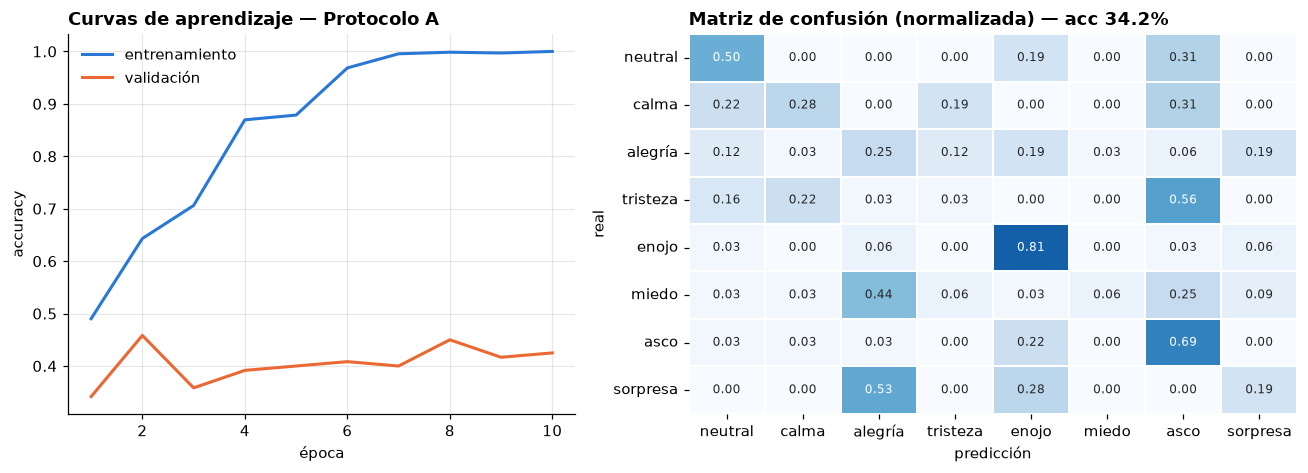

{'protocolo': 'Protocolo A',
 'accuracy': 0.3416666666666667,
 'f1_macro': 0.3012528577322402,
 'n_test': 240,
 'epocas': 10}

In [4]:
actor = df["actor"].values
idx_te = np.where(actor >= 21)[0]; idx_va = np.where((actor == 19) | (actor == 20))[0]; idx_tr = np.where(actor <= 18)[0]
tr, va, te = make_split(idx_tr, idx_va, idx_te)
print("train (aumentado)", len(tr[0]), "| val", len(va[0]), "| test", len(te[0]))
model_a, hist_a = train(tr, va)
res_a = evaluate("Protocolo A", model_a, te, hist_a)
torch.save(model_a.state_dict(), MODELS / "convser_protocolo_a.pt")
res_a

### Protocolo B — división aleatoria por clip (80/10/10, estratificada)

ep  1 loss 1.684 acc_tr 0.505 acc_val 0.347 (41s)


ep  2 loss 1.233 acc_tr 0.601 acc_val 0.417 (37s)


ep  3 loss 0.954 acc_tr 0.690 acc_val 0.431 (37s)


ep  4 loss 0.729 acc_tr 0.795 acc_val 0.438 (37s)


ep  5 loss 0.517 acc_tr 0.882 acc_val 0.493 (37s)


...

ep 24 loss 0.008 acc_tr 1.000 acc_val 0.597 (41s)


ep 25 loss 0.006 acc_tr 1.000 acc_val 0.583 (38s)


ep 26 loss 0.005 acc_tr 1.000 acc_val 0.597 (37s)


ep 27 loss 0.006 acc_tr 1.000 acc_val 0.597 (37s)


              precision    recall  f1-score   support

     neutral      0.471     0.800     0.593        10
       calma      0.682     0.789     0.732        19
     alegría      0.464     0.684     0.553        19
    tristeza      0.769     0.526     0.625        19
       enojo      0.727     0.842     0.780        19
       miedo      0.667     0.500     0.571        20
        asco      0.769     0.526     0.625        19
    sorpresa      0.714     0.526     0.606        19

    accuracy                          0.639       144
   macro avg      0.658     0.649     0.636       144
weighted avg      0.670     0.639     0.638       144



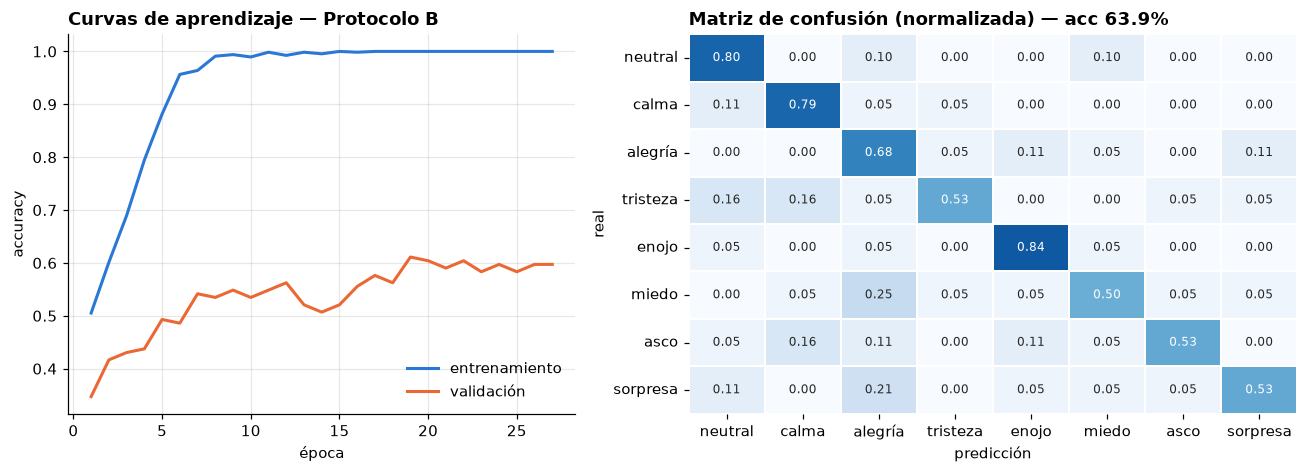

{'protocolo': 'Protocolo B',
 'accuracy': 0.6388888888888888,
 'f1_macro': 0.6356835476743364,
 'n_test': 144,
 'epocas': 27}

In [5]:
idx = np.arange(len(df))
idx_tr, idx_tmp = train_test_split(idx, test_size=0.2, stratify=df["y"], random_state=SEED)
idx_va, idx_te = train_test_split(idx_tmp, test_size=0.5, stratify=df["y"].values[idx_tmp], random_state=SEED)
tr, va, te = make_split(idx_tr, idx_va, idx_te)
model_b, hist_b = train(tr, va)
res_b = evaluate("Protocolo B", model_b, te, hist_b)
torch.save(model_b.state_dict(), MODELS / "convser_protocolo_b.pt")
res_b

## 3. Resumen

In [6]:
resumen = pd.DataFrame([res_a, res_b]).set_index("protocolo")
resumen.to_csv(OUT / "resumen_metricas.csv")
(OUT / "resumen_metricas.json").write_text(json.dumps([res_a, res_b], indent=2, default=float))
resumen.style.format({"accuracy": "{:.1%}", "f1_macro": "{:.3f}"})

,accuracy,f1_macro,n_test,epocas
protocolo,,,,
Protocolo A,34.2%,0.301,240,10
Protocolo B,63.9%,0.636,144,27


**Lectura de resultados.** La referencia reporta ~90 % sobre cuatro corpus combinados y con aumentación previa a la división
(lo que infla la métrica). Con solo RAVDESS, sin fuga y —en el protocolo A— con hablantes no vistos, la cifra esperada es menor;
la diferencia entre A y B cuantifica cuánto depende el modelo de conocer al hablante.